In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/airbnb_data.csv")
df.head()

/var/folders/ky/twz1wh510q938k2krxzw5lv00000gn/T/ipykernel_36990/150556409.py:6: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./data/airbnb_data.csv")


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [58]:
for col in df.columns:
    print(f"{col} has {df[col].isnull().sum()} nullish entries")
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"Mean: {df[col].mean()}\nMedian: {df[col].median()}\nStandard Deviation: {df[col].std()}\n")
    else:
        print(f"Num of unique values: {df[col].nunique()}\nValues: {df[col].unique() if df[col].nunique() < 10 else np.nan}\n")

id has 0 nullish entries
Mean: 29146234.522129845
Median: 29136603.0
Standard Deviation: 16257505.607308906

NAME has 250 nullish entries
Num of unique values: 61281
Values: nan

host id has 0 nullish entries
Mean: 49254111474.32867
Median: 49117739352.0
Standard Deviation: 28538996644.374817

host_identity_verified has 289 nullish entries
Num of unique values: 2
Values: ['unconfirmed' 'verified' nan]

host name has 406 nullish entries
Num of unique values: 13190
Values: nan

neighbourhood group has 29 nullish entries
Num of unique values: 7
Values: ['Brooklyn' 'Manhattan' 'brookln' 'manhatan' 'Queens' nan 'Staten Island'
 'Bronx']

neighbourhood has 16 nullish entries
Num of unique values: 224
Values: nan

lat has 8 nullish entries
Mean: 40.728093870371374
Median: 40.72229
Standard Deviation: 0.05585651602743888

long has 8 nullish entries
Mean: -73.94964395581123
Median: -73.95444
Standard Deviation: 0.04952126420255946

country has 532 nullish entries
Num of unique values: 1
Values:

In [59]:
df["number of reviews"].skew()

np.float64(3.839396215317322)

In [60]:
df["number of reviews"].kurtosis()

np.float64(25.029862183557565)

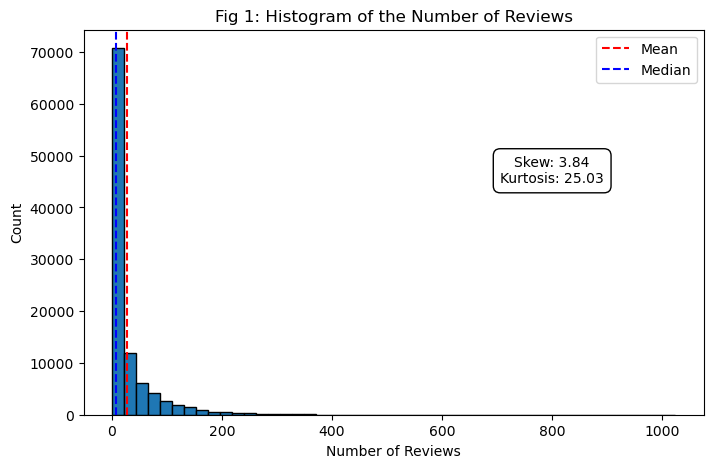

In [ ]:
df = df.dropna(subset="number of reviews")
bins = round(df["number of reviews"].count() ** (1/3))
plt.figure(figsize=(8,5))
plt.hist(x=df["number of reviews"],bins=bins,edgecolor="black")
plt.xlabel("Number of Reviews")
plt.ylabel("Count")
plt.title("Fig 1: Histogram of the Number of Reviews")
plt.axvline(x=df["number of reviews"].mean(),color="r",linestyle="--",label="Mean")
plt.axvline(x=df["number of reviews"].median(),color="b",linestyle="--",label="Median")
sk = df["number of reviews"].skew()
kurt = df["number of reviews"].kurt()
string = f"""Skew: {sk:.2f}
Kurtosis: {kurt:.2f}"""
plt.text(x=800,y=50000,s=string,ha="center",va="top",bbox={"boxstyle":"round, pad=0.5", "fc":"white"})
plt.legend()
plt.show()

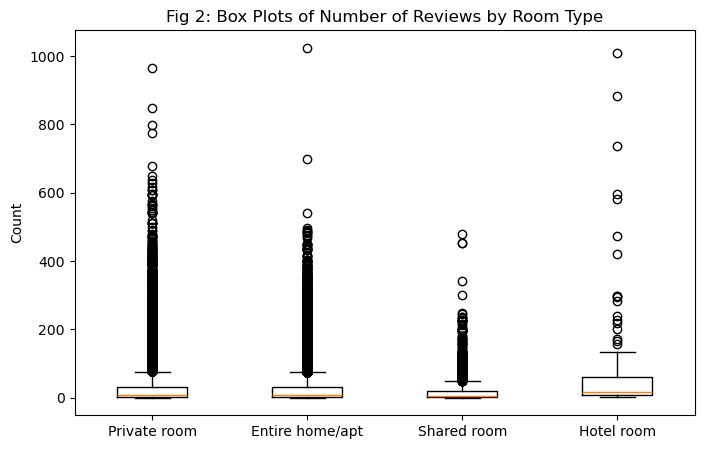

In [62]:
plt.figure(figsize=(8,5))
room = df["room type"].unique()
data = [df.loc[df["room type"] == p, "number of reviews"] for p in room]
plt.boxplot(x=data)
plt.xticks(ticks=range(1, len(room) + 1),labels=room)
plt.ylabel("Count")
plt.title("Fig 2: Box Plots of Number of Reviews by Room Type")
plt.show()

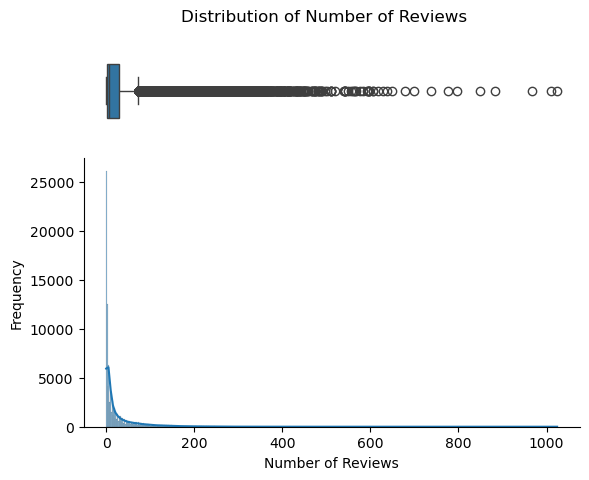

In [63]:
def generate_multiplot(df: pd.DataFrame, col: str, xlabel: str = "", title: str = "") -> None:
    fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, height_ratios = [2, 8])
    box = sns.boxplot(data = df, x = col, ax = ax1)
    hist = sns.histplot(data = df, x = col, ax = ax2, kde = True)
    box.set(yticks = [], xticks = [], xlabel = "")
    hist.set(xlabel = xlabel, ylabel = "Frequency")
    ax1.spines["bottom"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    fig.suptitle(title)

generate_multiplot(df, "number of reviews", "Number of Reviews", "Distribution of Number of Reviews")